In [2]:
import sys
!{sys.executable} -m pip install deepinv transformers

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\MSI-1\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import torch
import deepinv
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

device = "cuda"
batch_size = 32
image_size = 32

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.0,)) 
])

train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True
)
# train_loader = torch.utils.data.DataLoader(
#     datasets.CIFAR10(root="./data", train=True, download=True, transform=transform),
#     batch_size=batch_size,
#     shuffle=True
# )



c:\Users\MSI-1\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 9.91M/9.91M [00:05<00:00, 1.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 108kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 344kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 29.3kB/s]


In [5]:
a = next(iter(train_loader))

In [10]:
a[0].shape

torch.Size([32, 3, 32, 32])

In [11]:
a[0][0].shape

torch.Size([3, 32, 32])

In [13]:
import matplotlib.pyplot as plt

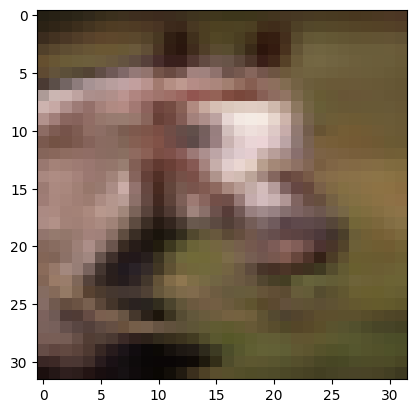

In [15]:
image = a[0][0].permute(1, 2, 0).numpy()
plt.imshow(image)
plt.show()


In [16]:
device

'cuda'

In [3]:
from tqdm import tqdm

lr = 1e-4
epochs = 100
model = deepinv.models.DiffUNet(in_channels=1, out_channels=1, pretrained=None).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = deepinv.loss.MSE()  

#Diffusion Constants
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


writer = SummaryWriter(log_dir="runs/diffusion_experiment")
global_step = 0

for epoch in range(epochs):
    model.train()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for data, _ in pbar:
        imgs = data.to(device)
        noise = torch.randn_like(imgs)
        t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
        
        noised_imgs = (
            sqrt_alphas_cumprod[t, None, None, None] * imgs + sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
        )
        
        optimizer.zero_grad()

        # unet_output = model(noised_imgs, t, type_t="timestep")
        
        # # Split the 6 channels into two chunks of 3 channels
        # # We only care about the first chunk (the estimated noise) for basic training
        # estimated_noise, estimated_variance = torch.chunk(unet_output, 2, dim=1)

        estimated_noise = model(noised_imgs, t, type_t="timestep")
        loss = mse(estimated_noise, noise).mean()
        loss.backward()
        optimizer.step()

        writer.add_scalar("Training/Loss", loss.item(), global_step)
        global_step += 1
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

writer.close()
torch.save(model.state_dict(), "diffusion_model.pth")

Epoch 1/100:  40%|███▉      | 744/1875 [05:05<07:44,  2.43it/s, loss=0.0222]


KeyboardInterrupt: 

In [3]:
import torch
import deepinv
from pathlib import Path
device = "cuda"
image_size = 32

checkpoint_path = "C:\\Users\\MSI-1\\Desktop\\Diffusion\\diffusion_model.pth"
model = deepinv.models.DiffUNet(
    in_channels=3, out_channels = 3, pretrained =  None
).to(device)

ckpt = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(ckpt, strict=False)

print("Model loaded successfully! Ready for generation.")


Model loaded successfully! Ready for generation.


In [7]:
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

model.eval()

n_samples = 32
with torch.no_grad():
    x = torch.randn(n_samples, 3, image_size, image_size).to(device)

    for t in reversed(range(timesteps)):
        t_tensor = torch.ones(n_samples, device=device).long() * t
        
        # 1. Get the full output from the U-Net
        unet_output = model(x, t_tensor, type_t="timestep")
        
        # 2. Slice it in half! We only want the noise prediction.
        predicted_noise, _ = torch.chunk(unet_output, 2, dim=1)
        
        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0

        # 3. The Math Step (Now with matching dimensions)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod)) * predicted_noise) + torch.sqrt(beta) * noise

# After the loop, 'x' contains your 32 fully generated cifar10 images!

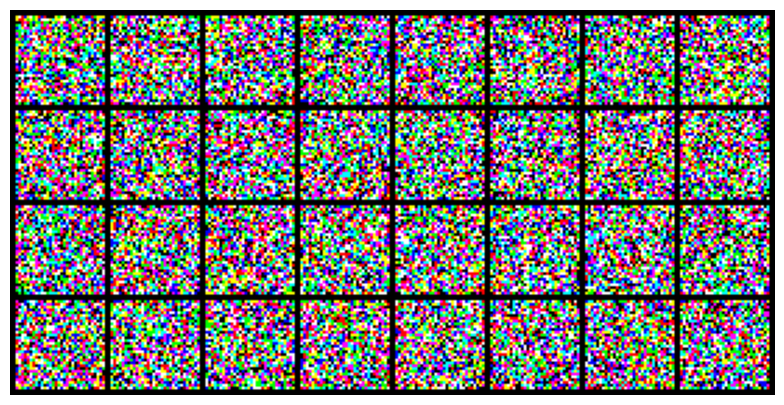

In [8]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Normalize from [-1, 1] back to [0, 1]
x_display = (x.clamp(-1, 1) + 1) / 2 

# Create a beautiful grid of your 32 images
grid = vutils.make_grid(x_display, nrow=8)

# Plot it!
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()